In [1]:
from google.colab import files
print("📁 Upload: filtered_variants.vcf")
print("Location: nust-genomics-variant-calling/results/vcf/filtered_variants.vcf\n")
uploaded = files.upload()
print(f"\n✅ Uploaded successfully!")

📁 Upload: filtered_variants.vcf
Location: nust-genomics-variant-calling/results/vcf/filtered_variants.vcf



Saving filtered_variants.vcf to filtered_variants.vcf

✅ Uploaded successfully!


In [2]:
import pandas as pd

# Parse VCF file
vcf_file = 'filtered_variants.vcf'
variants = []

with open(vcf_file) as f:
    for line in f:
        if line.startswith('#'):
            continue
        fields = line.strip().split('\t')
        chrom, pos, id_, ref, alt, qual, filt, info = fields[:8]

        # Extract DP from INFO field
        dp_match = [x.split('=')[1] for x in info.split(';') if x.startswith('DP=')]
        dp = int(dp_match[0]) if dp_match else 0

        variants.append({
            'Position': int(pos),
            'Ref': ref,
            'Alt': alt,
            'Quality': float(qual),
            'Depth': dp
        })

df = pd.DataFrame(variants)

print("\n" + "="*60)
print("BRCA1 VARIANT ANALYSIS")
print("="*60)
print(f"\nTotal variants: {len(df)}")
print(f"Quality: {df['Quality'].min():.0f} - {df['Quality'].max():.0f}")
print(f"Depth: {df['Depth'].min()} - {df['Depth'].max()}x\n")
print(df.head(10).to_string(index=False))


BRCA1 VARIANT ANALYSIS

Total variants: 50
Quality: 104 - 153
Depth: 37 - 72x

 Position Ref Alt  Quality  Depth
     2704   T   C  152.392     53
     7557   T   G  150.397     44
     7957   G   C  153.347     52
     8812   C   A  145.664     53
     9332   G   T  151.326     37
    12391   C   A  149.936     50
    23791   A   C  137.228     65
    25313   C   T  153.372     57
    25562   C   G  111.702     52
    26354   C   G  143.321     72


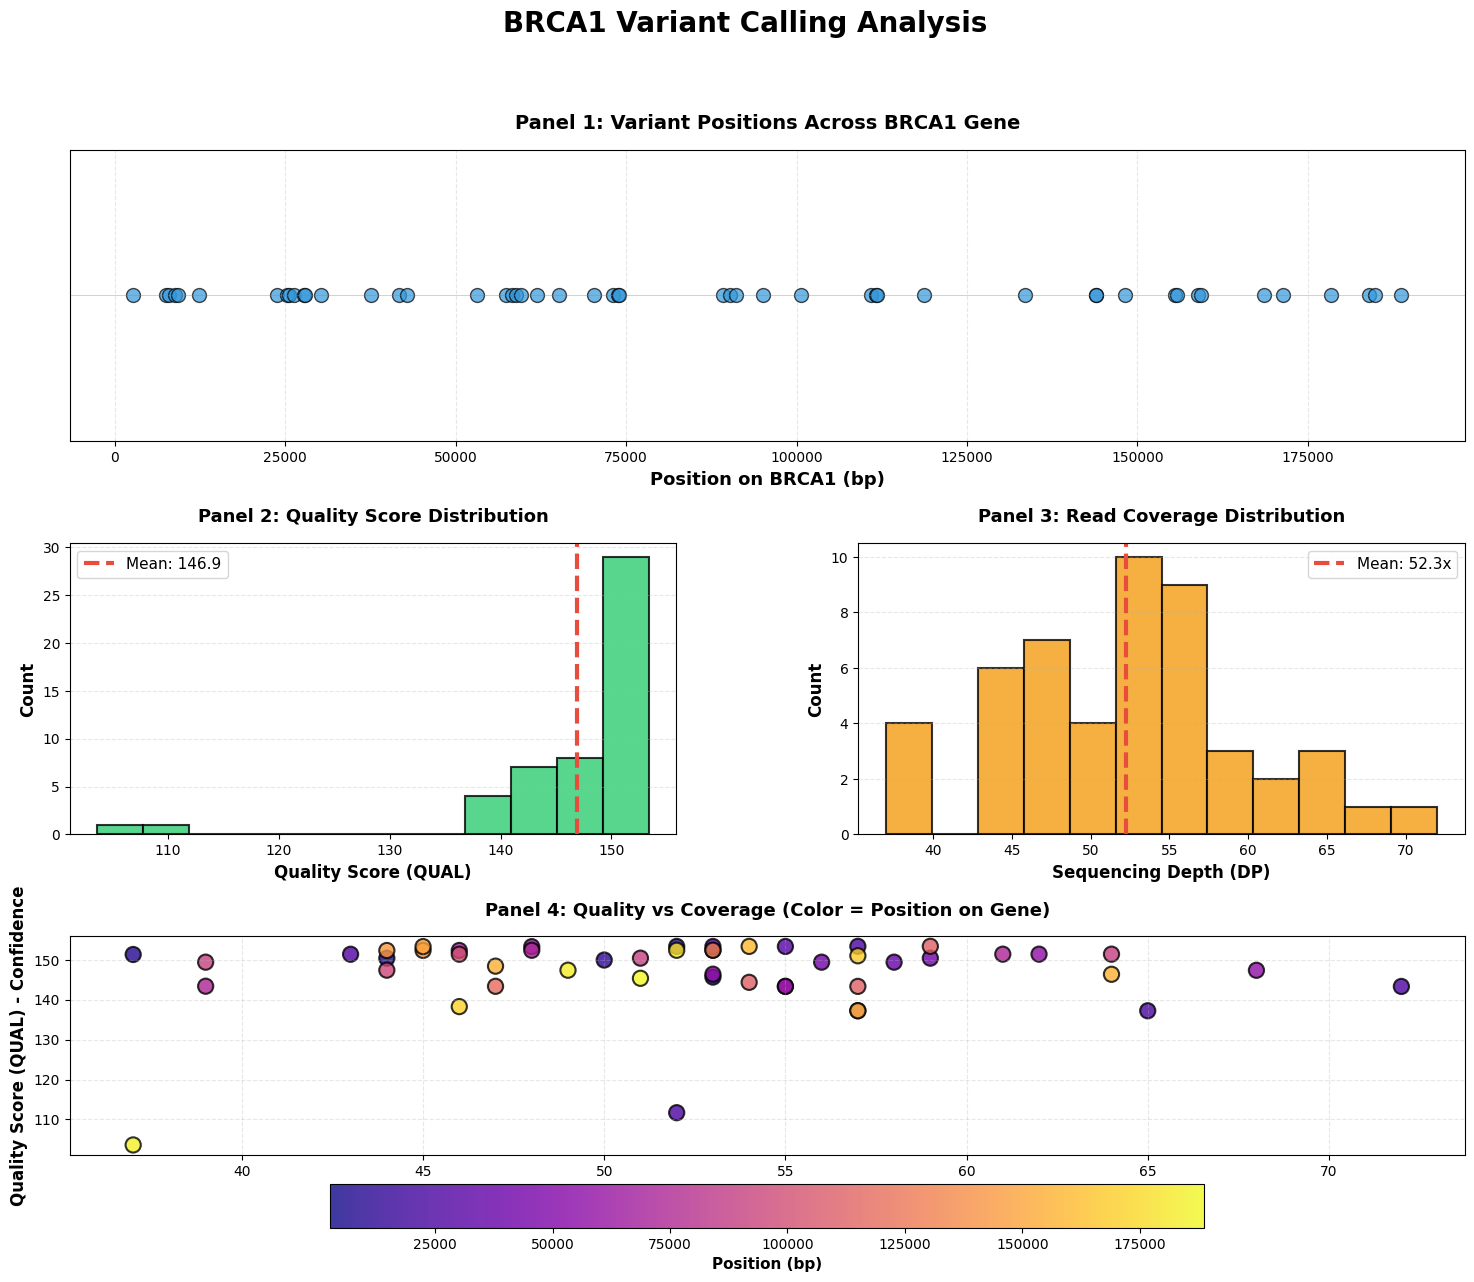

✅ Improved visualization created with proper spacing

📊 FIGURE EXPLANATION:
   Panel 1: Blue dots show WHERE variants located
   Panel 2: Green bars show quality confidence levels
   Panel 3: Orange bars show read coverage depth
   Panel 4: Colored dots show quality vs coverage relationship


In [6]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)

fig.suptitle('BRCA1 Variant Calling Analysis', fontsize=20, fontweight='bold', y=0.98)

# Panel 1: Variant positions (horizontal line with spaced dots)
ax1 = fig.add_subplot(gs[0, :])
ax1.scatter(df['Position'], [1]*len(df), s=100, alpha=0.7, color='#3498db', edgecolors='black', linewidth=1)
ax1.set_xlabel('Position on BRCA1 (bp)', fontsize=13, fontweight='bold')
ax1.set_ylabel('', fontsize=12)
ax1.set_title('Panel 1: Variant Positions Across BRCA1 Gene', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylim(0.8, 1.2)
ax1.set_yticks([])
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.axhline(y=1, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)

# Panel 2: Quality histogram (green bars, well spaced)
ax2 = fig.add_subplot(gs[1, 0])
counts, bins, patches = ax2.hist(df['Quality'], bins=12, color='#2ecc71', edgecolor='black', alpha=0.8, linewidth=1.5)
mean_qual = df['Quality'].mean()
ax2.axvline(mean_qual, color='#e74c3c', linestyle='--', linewidth=3, label=f'Mean: {mean_qual:.1f}')
ax2.set_xlabel('Quality Score (QUAL)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Count', fontsize=12, fontweight='bold')
ax2.set_title('Panel 2: Quality Score Distribution', fontsize=13, fontweight='bold', pad=15)
ax2.legend(fontsize=11, loc='upper left')
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Panel 3: Depth distribution (orange bars)
ax3 = fig.add_subplot(gs[1, 1])
counts, bins, patches = ax3.hist(df['Depth'], bins=12, color='#f39c12', edgecolor='black', alpha=0.8, linewidth=1.5)
mean_depth = df['Depth'].mean()
ax3.axvline(mean_depth, color='#e74c3c', linestyle='--', linewidth=3, label=f'Mean: {mean_depth:.1f}x')
ax3.set_xlabel('Sequencing Depth (DP)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Count', fontsize=12, fontweight='bold')
ax3.set_title('Panel 3: Read Coverage Distribution', fontsize=13, fontweight='bold', pad=15)
ax3.legend(fontsize=11, loc='upper right')
ax3.grid(axis='y', alpha=0.3, linestyle='--')

# Panel 4: Quality vs Depth (larger plot, less crowded)
ax4 = fig.add_subplot(gs[2, :])
scatter = ax4.scatter(df['Depth'], df['Quality'], s=120, c=df['Position'],
                      cmap='plasma', alpha=0.8, edgecolors='black', linewidth=1.5)
ax4.set_xlabel('Sequencing Depth (DP) - Read Support', fontsize=12, fontweight='bold')
ax4.set_ylabel('Quality Score (QUAL) - Confidence', fontsize=12, fontweight='bold')
ax4.set_title('Panel 4: Quality vs Coverage (Color = Position on Gene)', fontsize=13, fontweight='bold', pad=15)
ax4.grid(True, alpha=0.3, linestyle='--')
cbar = plt.colorbar(scatter, ax=ax4, orientation='horizontal', pad=0.1)
cbar.set_label('Position (bp)', fontsize=11, fontweight='bold')

plt.savefig('variant_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Improved visualization created with proper spacing")
print("\n📊 FIGURE EXPLANATION:")
print("   Panel 1: Blue dots show WHERE variants located")
print("   Panel 2: Green bars show quality confidence levels")
print("   Panel 3: Orange bars show read coverage depth")
print("   Panel 4: Colored dots show quality vs coverage relationship")

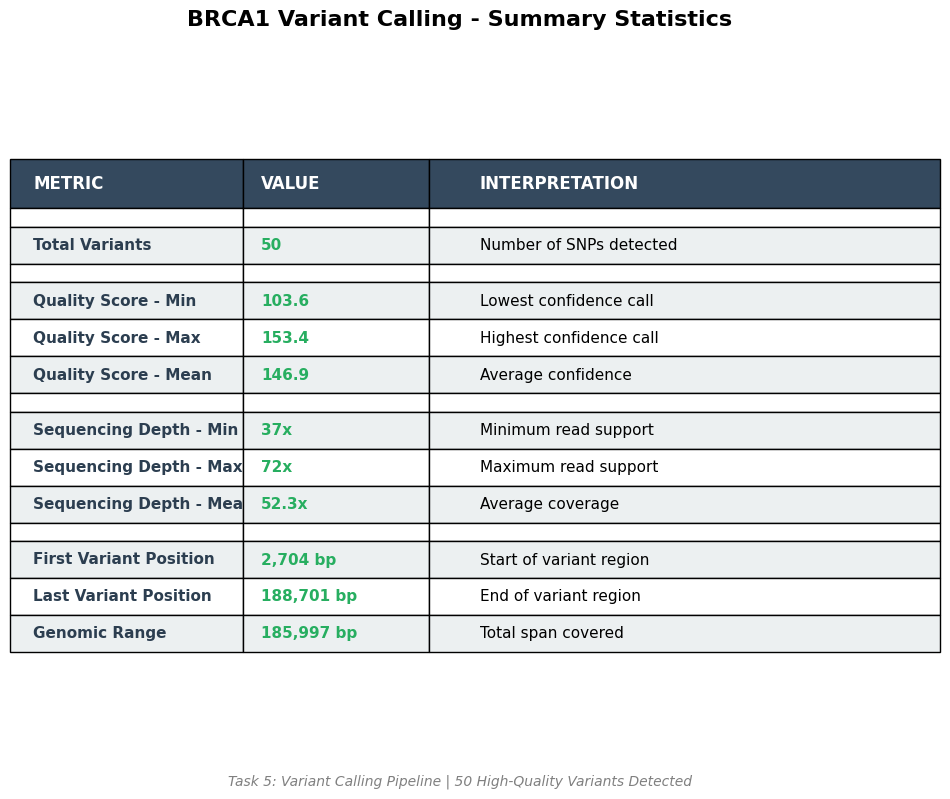

✅ Summary table image created: variant_summary_table.png

📋 TABLE SHOWS:
   - Total variants found
   - Quality score statistics (min, max, mean)
   - Sequencing depth statistics (min, max, mean)
   - Genomic position coverage (start, end, range)


In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('tight')
ax.axis('off')

# Create summary data
summary_data = [
    ['METRIC', 'VALUE', 'INTERPRETATION'],
    ['', '', ''],
    ['Total Variants', f'{len(df)}', 'Number of SNPs detected'],
    ['', '', ''],
    ['Quality Score - Min', f'{df["Quality"].min():.1f}', 'Lowest confidence call'],
    ['Quality Score - Max', f'{df["Quality"].max():.1f}', 'Highest confidence call'],
    ['Quality Score - Mean', f'{df["Quality"].mean():.1f}', 'Average confidence'],
    ['', '', ''],
    ['Sequencing Depth - Min', f'{df["Depth"].min()}x', 'Minimum read support'],
    ['Sequencing Depth - Max', f'{df["Depth"].max()}x', 'Maximum read support'],
    ['Sequencing Depth - Mean', f'{df["Depth"].mean():.1f}x', 'Average coverage'],
    ['', '', ''],
    ['First Variant Position', f'{df["Position"].min():,} bp', 'Start of variant region'],
    ['Last Variant Position', f'{df["Position"].max():,} bp', 'End of variant region'],
    ['Genomic Range', f'{df["Position"].max() - df["Position"].min():,} bp', 'Total span covered'],
]

# Create table
table = ax.table(cellText=summary_data, cellLoc='left', loc='center',
                colWidths=[0.25, 0.2, 0.55])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Style header row
for i in range(3):
    cell = table[(0, i)]
    cell.set_facecolor('#34495e')
    cell.set_text_props(weight='bold', color='white', fontsize=12)
    cell.set_height(0.08)

# Style data rows with alternating colors
for i in range(1, len(summary_data)):
    for j in range(3):
        cell = table[(i, j)]
        if summary_data[i][0] == '':  # Spacer rows
            cell.set_facecolor('white')
            cell.set_height(0.03)
        elif i % 2 == 0:
            cell.set_facecolor('#ecf0f1')
            cell.set_height(0.06)
        else:
            cell.set_facecolor('#ffffff')
            cell.set_height(0.06)

        # Bold the metric names
        if j == 0 and summary_data[i][0] != '':
            cell.set_text_props(weight='bold', color='#2c3e50')
        elif j == 1:
            cell.set_text_props(weight='bold', color='#27ae60', fontsize=11)

# Add title
fig.text(0.5, 0.97, 'BRCA1 Variant Calling - Summary Statistics',
         ha='center', fontsize=16, fontweight='bold')

# Add footer
fig.text(0.5, 0.02, 'Task 5: Variant Calling Pipeline | 50 High-Quality Variants Detected',
         ha='center', fontsize=10, style='italic', color='gray')

plt.savefig('variant_summary_table.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("✅ Summary table image created: variant_summary_table.png")
print("\n📋 TABLE SHOWS:")
print("   - Total variants found")
print("   - Quality score statistics (min, max, mean)")
print("   - Sequencing depth statistics (min, max, mean)")
print("   - Genomic position coverage (start, end, range)")

In [9]:
from google.colab import files

print("📥 Downloading images...\n")

files.download('variant_analysis.png')
files.download('variant_summary_table.png')

print("\n✅ Downloads started!")
print("\nFiles saved to your Downloads folder:")
print("   1. variant_analysis.png (4-panel analysis)")
print("   2. variant_summary_table.png (statistics table)")

📥 Downloading images...



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Downloads started!

Files saved to your Downloads folder:
   1. variant_analysis.png (4-panel analysis)
   2. variant_summary_table.png (statistics table)
